In [1]:
%matplotlib widget
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tpc5
import DataProcessor

import glob
import os

In [2]:
DATA_PATH = "../Expermant/T0076/t0076.exp/data"
DATA_PATHS = glob.glob(os.path.join(DATA_PATH, "*.tpc5"))
DATA_PATHS.sort()
print("There are total", len(DATA_PATHS), "files.")
DATA_PATHS = DATA_PATHS[6:9]

There are total 9 files.


In [3]:
SENSOR_X = np.array([   0,  0.08,  0.25])
SENSOR_Y = np.array([-0.1,   0.1,  -0.1])
SENSOR_R = np.sqrt(SENSOR_X**2 + SENSOR_Y**2)

Processing file: ../Expermant/T0076/t0076.exp/data/t0076_1mm_60cm_7.tpc5
2e-07
Sample rate (MHz): 5.0
2e-07
Sample rate (MHz): 5.0
2e-07
Sample rate (MHz): 5.0


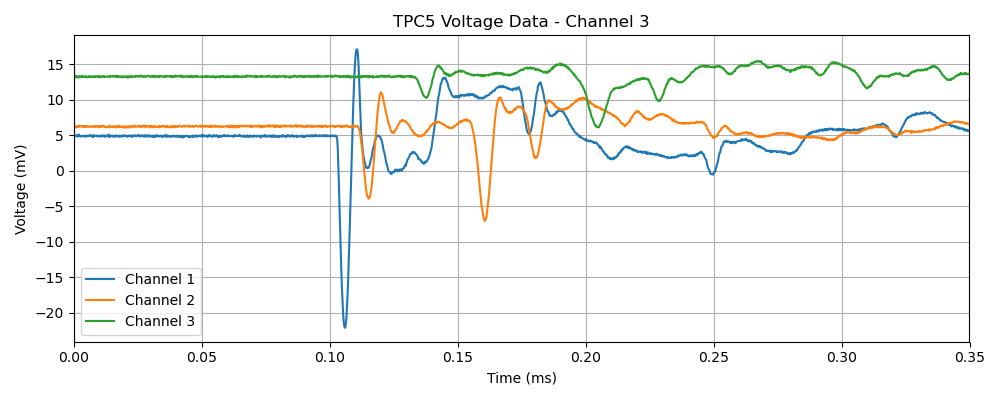

Processing file: ../Expermant/T0076/t0076.exp/data/t0076_1mm_60cm_8.tpc5
2e-07
Sample rate (MHz): 5.0
2e-07
Sample rate (MHz): 5.0
2e-07
Sample rate (MHz): 5.0


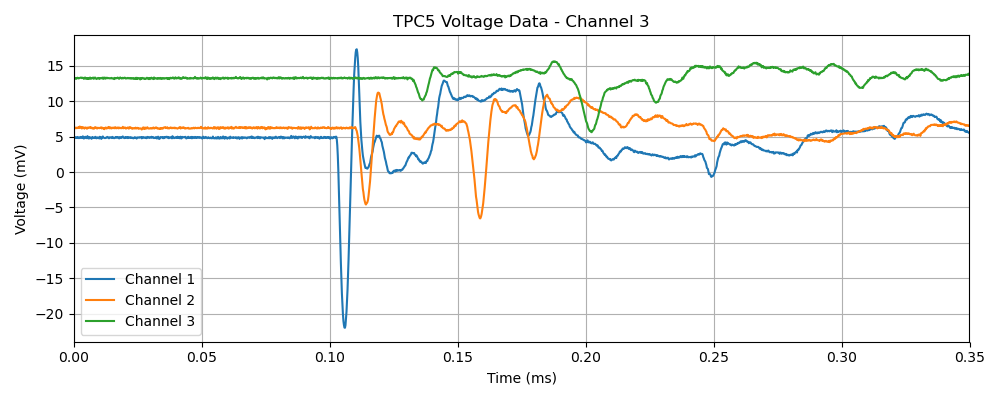

Processing file: ../Expermant/T0076/t0076.exp/data/t0076_1mm_60cm_9.tpc5
2e-07
Sample rate (MHz): 5.0
2e-07
Sample rate (MHz): 5.0
2e-07
Sample rate (MHz): 5.0


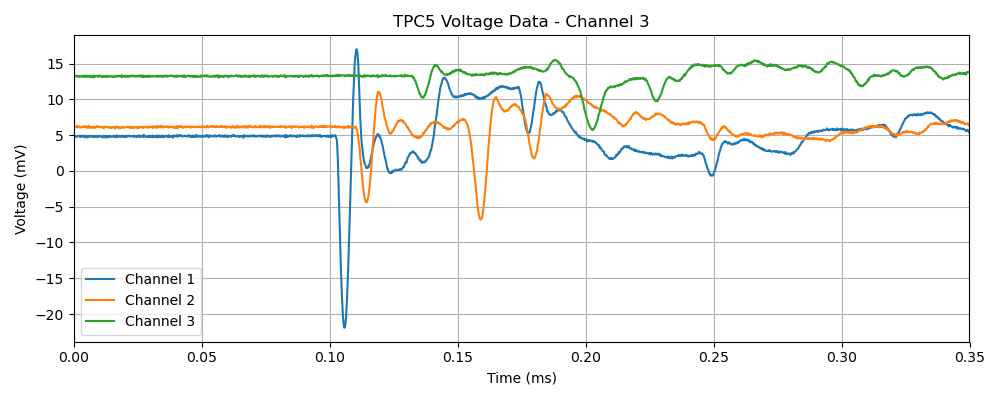

In [4]:
for data_path in DATA_PATHS:

    print(f"Processing file: {data_path}")

    with h5py.File(data_path, 'r') as file:
        ch_group  = file['/measurements/00000001/channels']
        available = sorted(int(ch) for ch in ch_group.keys())

        plt.figure(figsize=(10, 4))
        for ch in available:
            VOLTAGE  = tpc5.getVoltageData(file, ch)
            fs = tpc5.getSampleRate(file, ch)
            dt = 1.0 / fs

            print(dt)
            print("Sample rate (MHz):", fs / 1e6)

            TIME_S = np.arange(len(VOLTAGE)) * dt
            TIME_S -= 0.12572
            TIME_MS = TIME_S * 1e3

            plt.plot(TIME_MS, VOLTAGE * 1e3 + SENSOR_R[ch - 1] * 50, label=f'Channel {ch}')
            plt.title(f'TPC5 Voltage Data - Channel {ch}')
            plt.xlabel('Time (ms)')
            plt.ylabel('Voltage (mV)')
            plt.xlim(0, 0.35)
            plt.grid()
            plt.legend()
            plt.tight_layout()
        plt.show()

Processing file: ../Expermant/T0076/t0076.exp/data/t0076_1mm_60cm_7.tpc5
dt: 2e-07
Sample rate (MHz): 5.0
Channel 1: Peak in 0.5–1.0 MHz = 0.581 MHz, Amp = 5.53
Channel 1: Peak in 1.0–1.5 MHz = 1.019 MHz, Amp = 12.57


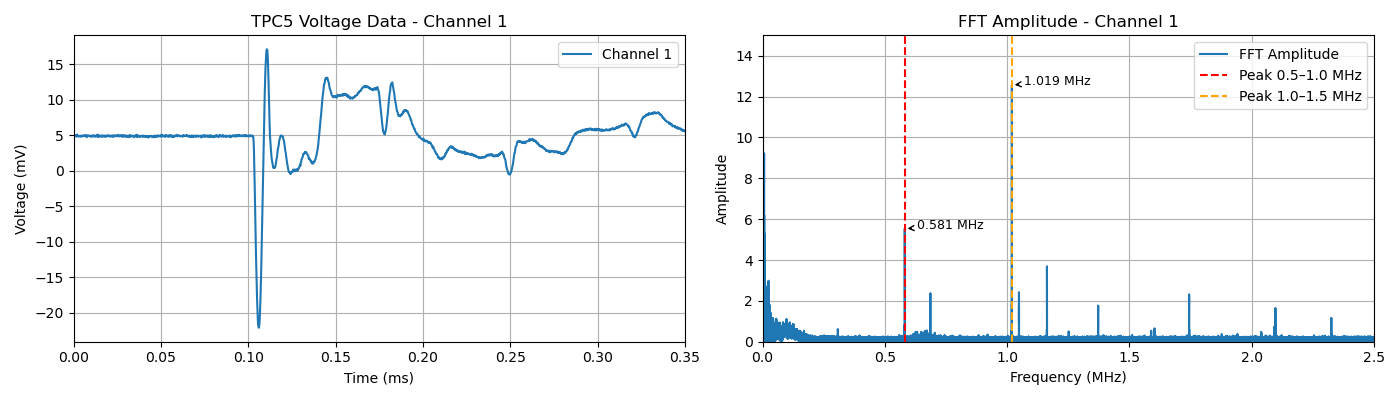

dt: 2e-07
Sample rate (MHz): 5.0
Channel 2: Peak in 0.5–1.0 MHz = 0.581 MHz, Amp = 6.22
Channel 2: Peak in 1.0–1.5 MHz = 1.019 MHz, Amp = 7.86


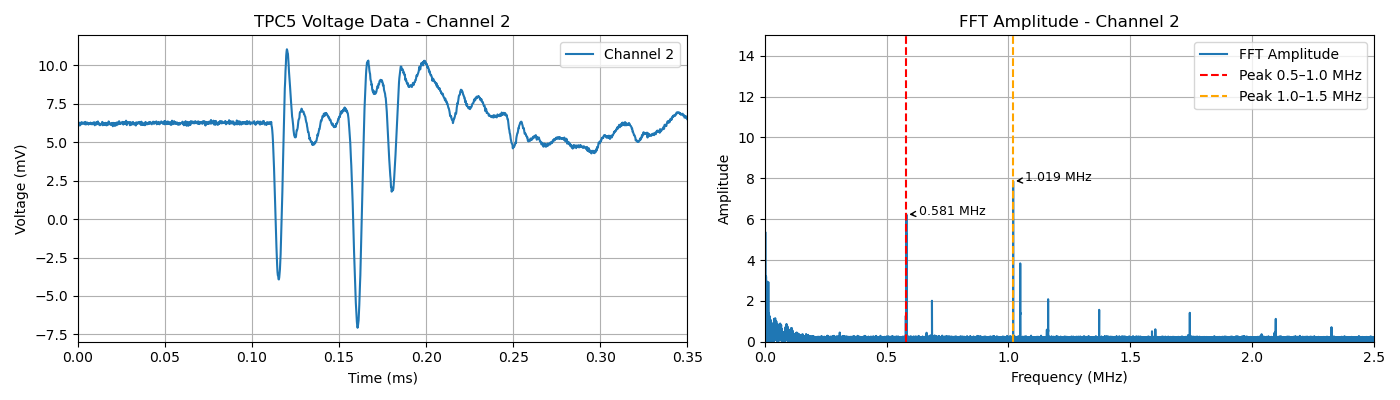

dt: 2e-07
Sample rate (MHz): 5.0
Channel 3: Peak in 0.5–1.0 MHz = 0.581 MHz, Amp = 3.53
Channel 3: Peak in 1.0–1.5 MHz = 1.019 MHz, Amp = 6.30


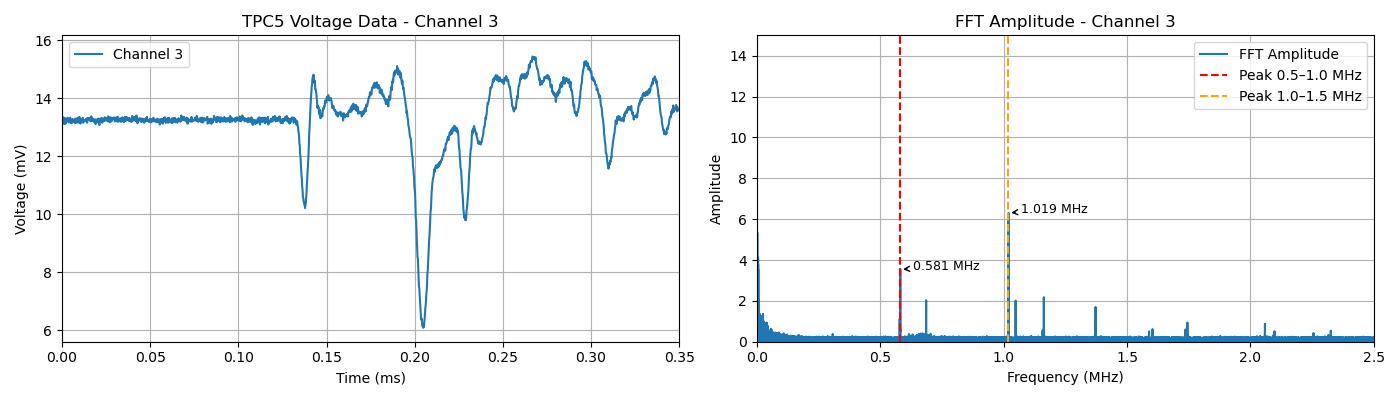

Processing file: ../Expermant/T0076/t0076.exp/data/t0076_1mm_60cm_8.tpc5
dt: 2e-07
Sample rate (MHz): 5.0
Channel 1: Peak in 0.5–1.0 MHz = 0.581 MHz, Amp = 4.91
Channel 1: Peak in 1.0–1.5 MHz = 1.019 MHz, Amp = 15.24


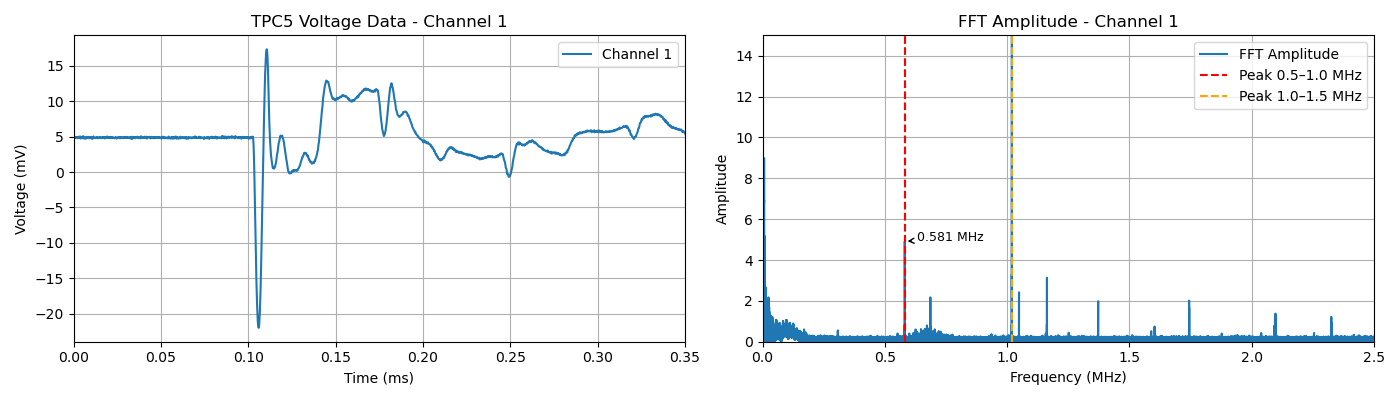

dt: 2e-07
Sample rate (MHz): 5.0
Channel 2: Peak in 0.5–1.0 MHz = 0.581 MHz, Amp = 5.80
Channel 2: Peak in 1.0–1.5 MHz = 1.019 MHz, Amp = 9.52


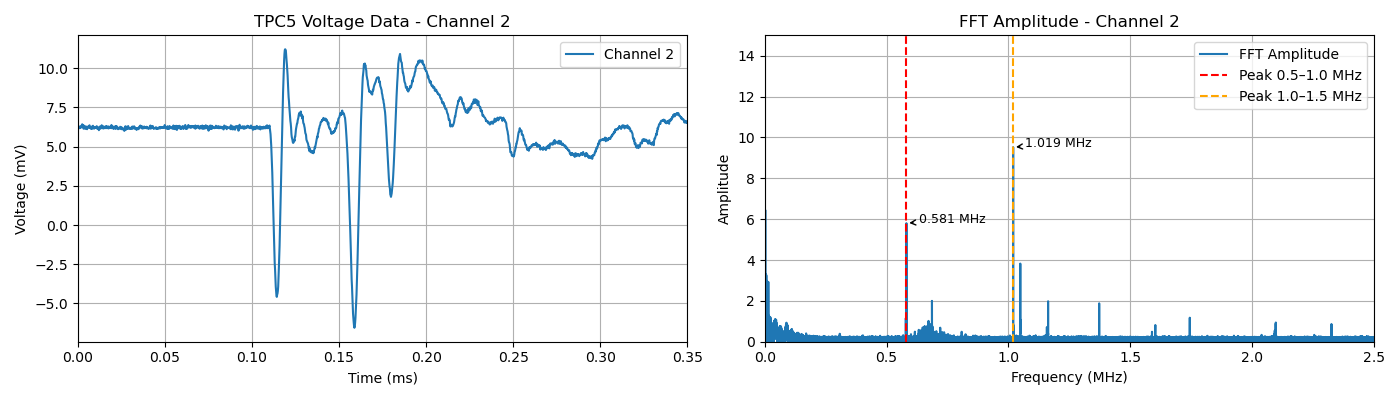

dt: 2e-07
Sample rate (MHz): 5.0
Channel 3: Peak in 0.5–1.0 MHz = 0.581 MHz, Amp = 3.23
Channel 3: Peak in 1.0–1.5 MHz = 1.019 MHz, Amp = 7.72


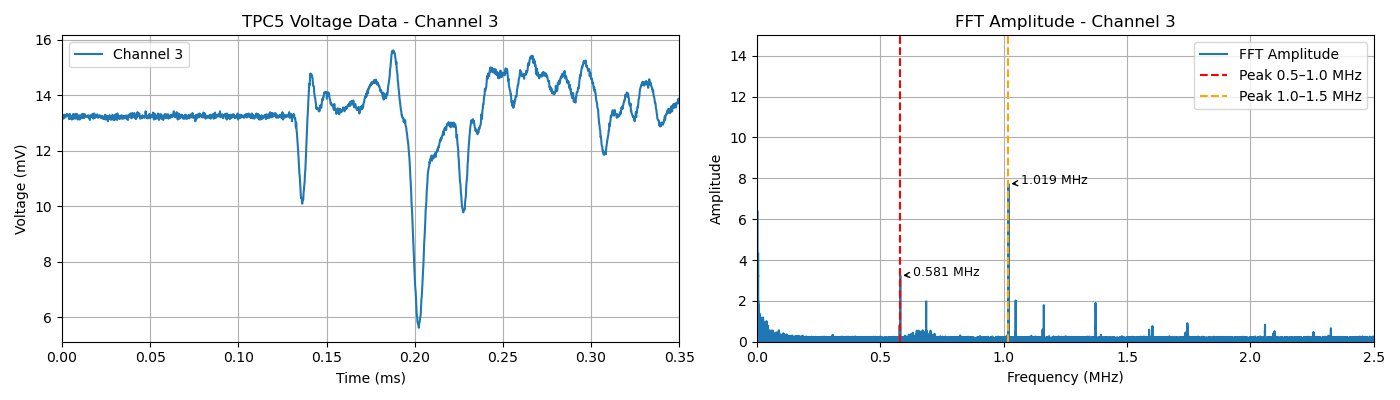

Processing file: ../Expermant/T0076/t0076.exp/data/t0076_1mm_60cm_9.tpc5
dt: 2e-07
Sample rate (MHz): 5.0
Channel 1: Peak in 0.5–1.0 MHz = 0.581 MHz, Amp = 8.15
Channel 1: Peak in 1.0–1.5 MHz = 1.019 MHz, Amp = 11.50


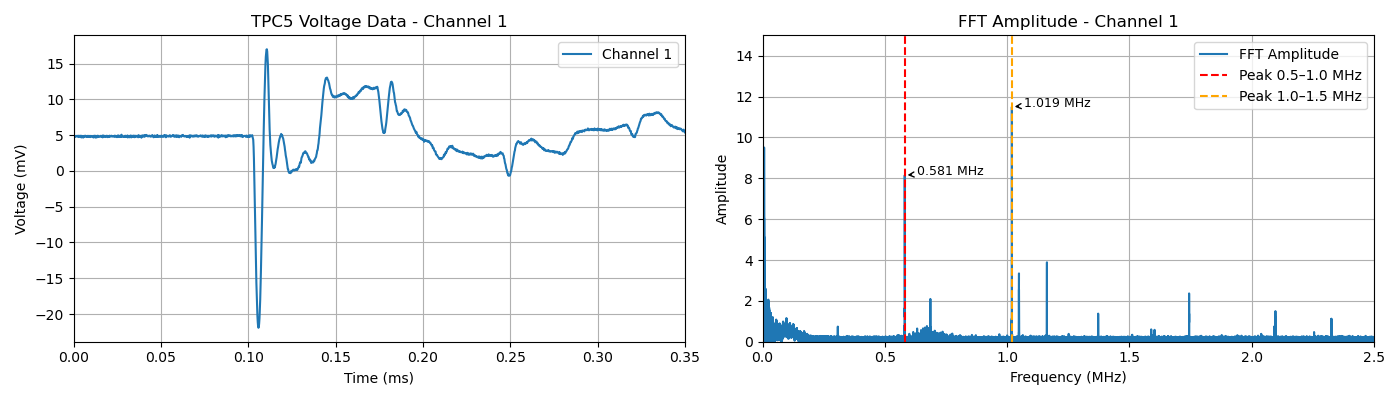

dt: 2e-07
Sample rate (MHz): 5.0
Channel 2: Peak in 0.5–1.0 MHz = 0.581 MHz, Amp = 9.14
Channel 2: Peak in 1.0–1.5 MHz = 1.019 MHz, Amp = 7.11


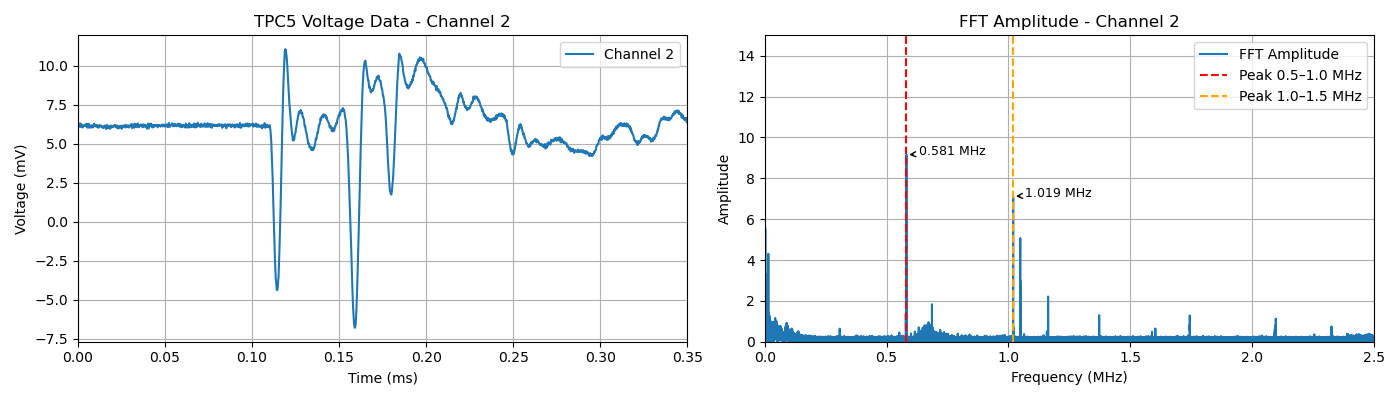

dt: 2e-07
Sample rate (MHz): 5.0
Channel 3: Peak in 0.5–1.0 MHz = 0.581 MHz, Amp = 5.22
Channel 3: Peak in 1.0–1.5 MHz = 1.019 MHz, Amp = 5.79


/var/folders/3_/nmxnf4m14bq6l5lt8nd299xh0000gp/T/ipykernel_47899/1613510120.py:44: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 2, figsize=(14, 4))


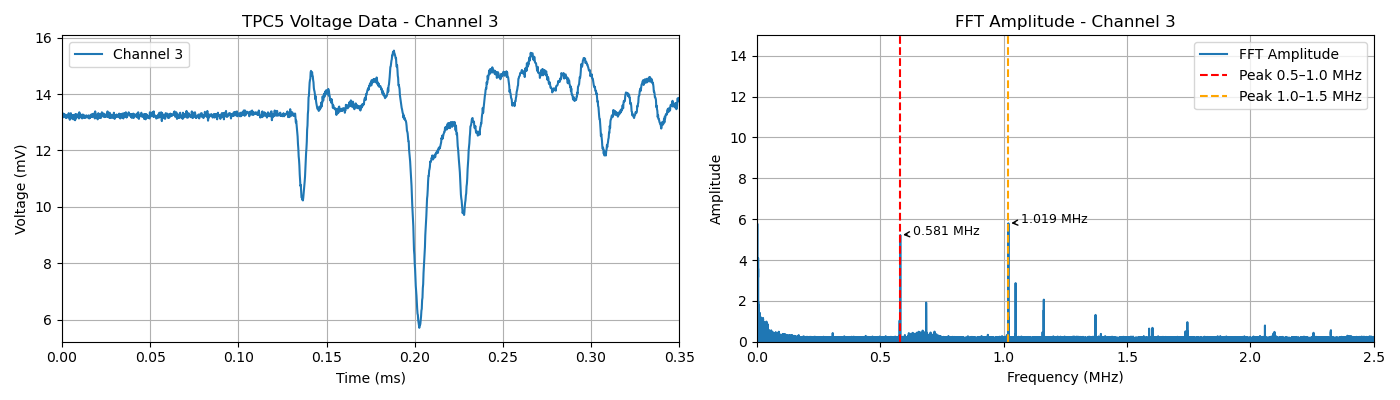

In [6]:
for data_path in DATA_PATHS:

    print(f"Processing file: {data_path}")

    with h5py.File(data_path, 'r') as file:
        ch_group  = file['/measurements/00000001/channels']
        available = sorted(int(ch) for ch in ch_group.keys())

        for ch in available:
            VOLTAGE = tpc5.getVoltageData(file, ch)
            fs = tpc5.getSampleRate(file, ch)  # Sample rate in Hz
            dt = 1.0 / fs

            print("dt:", dt)
            print("Sample rate (MHz):", fs / 1e6)

            TIME_S = np.arange(len(VOLTAGE)) * dt
            TIME_S -= 0.12572
            TIME_MS = TIME_S * 1e3

            # === FFT calculation ===
            N = len(VOLTAGE)
            freq = np.fft.rfftfreq(N, d=dt)  # in Hz
            fft_vals = np.fft.rfft(VOLTAGE)
            fft_amp = np.abs(fft_vals)

            # === Find peaks in specific frequency ranges ===
            freq_mhz = freq / 1e6  # convert to MHz

            def find_peak_in_band(f, amp, band_start, band_end):
                idx_band = np.where((f >= band_start) & (f <= band_end))[0]
                if len(idx_band) == 0:
                    return None, None
                idx_max = idx_band[np.argmax(amp[idx_band])]
                return f[idx_max], amp[idx_max]

            peak_1_freq, peak_1_amp = find_peak_in_band(freq_mhz, fft_amp, 0.5, 1.0)
            peak_2_freq, peak_2_amp = find_peak_in_band(freq_mhz, fft_amp, 1.0, 1.5)

            print(f"Channel {ch}: Peak in 0.5–1.0 MHz = {peak_1_freq:.3f} MHz, Amp = {peak_1_amp:.2f}")
            print(f"Channel {ch}: Peak in 1.0–1.5 MHz = {peak_2_freq:.3f} MHz, Amp = {peak_2_amp:.2f}")

            # === Plotting ===
            fig, axs = plt.subplots(1, 2, figsize=(14, 4))

            # Time-domain plot
            axs[0].plot(TIME_MS, VOLTAGE * 1e3 + SENSOR_R[ch - 1] * 50, label=f'Channel {ch}')
            axs[0].set_title(f'TPC5 Voltage Data - Channel {ch}')
            axs[0].set_xlabel('Time (ms)')
            axs[0].set_ylabel('Voltage (mV)')
            axs[0].set_xlim(0, 0.35)
            axs[0].grid(True)
            axs[0].legend()

            # FFT amplitude plot
            axs[1].plot(freq_mhz, fft_amp, label='FFT Amplitude')
            axs[1].set_title(f'FFT Amplitude - Channel {ch}')
            axs[1].set_xlabel('Frequency (MHz)')
            axs[1].set_ylabel('Amplitude')
            axs[1].set_xlim(0, fs / 2 / 1e6)
            axs[1].set_ylim(0, 15)
            axs[1].grid(True)

            # Add vertical lines and annotations for peaks
            if peak_1_freq is not None:
                axs[1].axvline(x=peak_1_freq, color='red', linestyle='--', label='Peak 0.5–1.0 MHz')
                axs[1].annotate(f'{peak_1_freq:.3f} MHz', xy=(peak_1_freq, peak_1_amp),
                                xytext=(peak_1_freq + 0.05, peak_1_amp),
                                arrowprops=dict(arrowstyle='->'), fontsize=9)
            if peak_2_freq is not None:
                axs[1].axvline(x=peak_2_freq, color='orange', linestyle='--', label='Peak 1.0–1.5 MHz')
                axs[1].annotate(f'{peak_2_freq:.3f} MHz', xy=(peak_2_freq, peak_2_amp),
                                xytext=(peak_2_freq + 0.05, peak_2_amp),
                                arrowprops=dict(arrowstyle='->'), fontsize=9)

            axs[1].legend()

            plt.tight_layout()
            plt.show()